# SETR-PUP: Pure Transformer Encoder for Polyp Segmentation

**Paper:** *Rethinking Semantic Segmentation from a Sequence-to-Sequence Perspective with Transformers* (Zheng et al., CVPR 2021)

**Dataset:** Kvasir-SEG — 1,000 colonoscopy images with expert-annotated binary polyp masks

---

## What We Are Building

SETR (SEgmentation TRansformer) replaces the CNN encoder entirely with a **pure Vision Transformer (ViT)**. Instead of downsampling feature maps through convolutional stages, SETR:

1. Splits the image into **16×16 fixed-size patches**
2. Flattens and linearly projects each patch into a **token embedding**
3. Passes the token sequence through **12 Transformer encoder layers** (ViT-Base)
4. Decodes the output tokens back to a full-resolution mask using **Progressive UPsampling (PUP)**

The key insight: **spatial resolution never reduces in the encoder.** Every patch token attends to every other patch at every layer — true global context from the very first layer.

### Why SETR-PUP for Polyps?

I use the **PUP decoder variant** specifically because:
- Polyp boundaries are subtle and irregular — progressive 2× upsampling recovers them more carefully than a single 16× jump (Naive) 
- Binary segmentation (polyp vs background) does not need the deep semantic hierarchy of SETR-MLA (designed for multi-class scene parsing)
- PUP is cleaner to implement and more stable to train

### Architecture Overview

```
Input Image (3 × 352 × 352)
        ↓
Patch Embedding  →  (3×3 conv stride 16, or linear projection)
        ↓
Sequence of 484 tokens  (22×22 grid, each token = 768-dim)
        ↓
ViT-Base Encoder  →  12 × [LayerNorm → MSA → LayerNorm → MLP]
        ↓
Output Tokens  (484 × 768)
        ↓
Reshape to 2D  →  (768 × 22 × 22)
        ↓
PUP Decoder  →  4 × [Conv → BN → ReLU → 2× Upsample]
        ↓
Segmentation Mask  (1 × 352 × 352)
```

---

## Step 1: Install Dependencies

Kaggle notebooks come with PyTorch pre-installed. We only need `timm` (PyTorch Image Models) which provides the pretrained ViT-Base backbone — this is critical since training a pure Transformer from scratch on 800 images would not converge.

In [1]:
!pip install timm -q

## Step 2: Imports

In [2]:
import os
import random
import numpy as np
from PIL import Image
from glob import glob

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import timm
import matplotlib.pyplot as plt
from tqdm import tqdm

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Step 3: Dataset Paths

The Kvasir-SEG dataset on Kaggle has the following structure:

```
kvasir-seg/
├── images/       ← 1000 colonoscopy images (.jpg)
└── masks/        ← 1000 binary segmentation masks (.jpg)
                     (same filename as corresponding image)
```

Images and masks share **identical filenames** — pairing them is straightforward.

> **Note:** Update `DATA_ROOT` below to match the Kaggle dataset path. Common paths:
> - `/kaggle/input/kvasirseg/kvasir-seg/`  
> - `/kaggle/input/kvasir-seg-dataset/Kvasir-SEG/`

In [4]:
# ── Update this path to your Kaggle dataset location ──
DATA_ROOT = '/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG'

IMAGE_DIR = os.path.join(DATA_ROOT, 'images')
MASK_DIR  = os.path.join(DATA_ROOT, 'masks')

# Collect all image paths and sort for reproducibility
image_paths = sorted(glob(os.path.join(IMAGE_DIR, '*.jpg')))
mask_paths  = sorted(glob(os.path.join(MASK_DIR,  '*.jpg')))

print(f'Total images : {len(image_paths)}')
print(f'Total masks  : {len(mask_paths)}')

# Sanity check — filenames must match
for img, msk in zip(image_paths[:5], mask_paths[:5]):
    assert os.path.basename(img) == os.path.basename(msk), 'Filename mismatch!'
print('Filename pairing check passed ✓')

Total images : 1000
Total masks  : 1000
Filename pairing check passed ✓


## Step 4: Train / Validation / Test Split

We follow the canonical Kvasir-SEG split: **800 train / 100 validation / 100 test** (80/10/10).

We shuffle before splitting to avoid any ordering bias in the dataset files.

In [6]:
# Shuffle together
combined = list(zip(image_paths, mask_paths))
random.shuffle(combined)
image_paths, mask_paths = zip(*combined)

# Split
train_images, train_masks = image_paths[:800],  mask_paths[:800]
val_images,   val_masks   = image_paths[800:900], mask_paths[800:900]
test_images,  test_masks  = image_paths[900:],  mask_paths[900:]

print(f'Train : {len(train_images)} | Val : {len(val_images)} | Test : {len(test_images)}')

Train : 800 | Val : 100 | Test : 100


## Step 5: Dataset & Augmentation

### Image Size

ViT-Base uses **16×16 patches**. We resize images to **352×352** so that:
- 352 / 16 = **22 patches per side → 484 tokens total**
- Size is compatible with ViT-Base pretrained weights (which expect 224 or 384; we use `img_size=352` in timm)

### Augmentation Strategy

Since I have only 800 training images, augmentation is critical. We apply:
- **Horizontal & Vertical flips** — polyps can appear anywhere
- **Random rotation ±15°** — endoscope orientation varies
- **Color jitter** — lighting and color temperature varies across colonoscopes
- **Normalization** — ImageNet mean/std since we use ImageNet pretrained ViT weights

> Important: augmentations that modify **spatial geometry** (flip, rotate) must be applied **identically to both image and mask** to keep them aligned. Color jitter is applied to the **image only**.

In [8]:
IMG_SIZE   = 352
PATCH_SIZE = 16
NUM_TOKENS = (IMG_SIZE // PATCH_SIZE) ** 2   # 484

# ImageNet normalization (required for pretrained ViT)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class PolypDataset(Dataset):
    """
    Kvasir-SEG Dataset.

    Returns:
        image : FloatTensor (3, H, W) — normalized with ImageNet stats
        mask  : FloatTensor (1, H, W) — binary {0.0, 1.0}
    """

    def __init__(self, image_paths, mask_paths, img_size=IMG_SIZE, augment=False):
        self.image_paths = list(image_paths)
        self.mask_paths  = list(mask_paths)
        self.img_size    = img_size
        self.augment     = augment

        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        self.color_jitter = transforms.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load
        image = Image.open(self.image_paths[idx]).convert('RGB')
        mask  = Image.open(self.mask_paths[idx]).convert('L')   # grayscale

        # Resize both to same size
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask  = mask.resize((self.img_size, self.img_size),  Image.NEAREST)

        # ── Augmentation (train only) ──────────────────────────────────
        if self.augment:
            # Horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)

            # Vertical flip
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask  = TF.vflip(mask)

            # Random rotation ±15 degrees
            if random.random() > 0.5:
                angle = random.uniform(-15, 15)
                image = TF.rotate(image, angle, interpolation=Image.BILINEAR)
                mask  = TF.rotate(mask,  angle, interpolation=Image.NEAREST)

            # Color jitter — image only, NOT mask
            if random.random() > 0.5:
                image = self.color_jitter(image)

        # ── To Tensor ─────────────────────────────────────────────────
        image = TF.to_tensor(image)          # (3, H, W), range [0, 1]
        mask  = TF.to_tensor(mask)           # (1, H, W), range [0, 1]

        # Normalize image with ImageNet stats
        image = self.normalize(image)

        # Binarize mask: threshold at 0.5 → {0.0, 1.0}
        mask = (mask > 0.5).float()

        return image, mask


# ── Datasets ──────────────────────────────────────────────────────────────────
train_dataset = PolypDataset(train_images, train_masks, augment=True)
val_dataset   = PolypDataset(val_images,   val_masks,   augment=False)
test_dataset  = PolypDataset(test_images,  test_masks,  augment=False)

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 8  # Reduce to 4 if GPU OOM

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 100
Val   batches : 13
Test  batches : 13


## Step 6: Visualize a Sample

Always sanity-check your dataset before training. We verify that image-mask pairs are correctly aligned and that the mask is properly binarized.

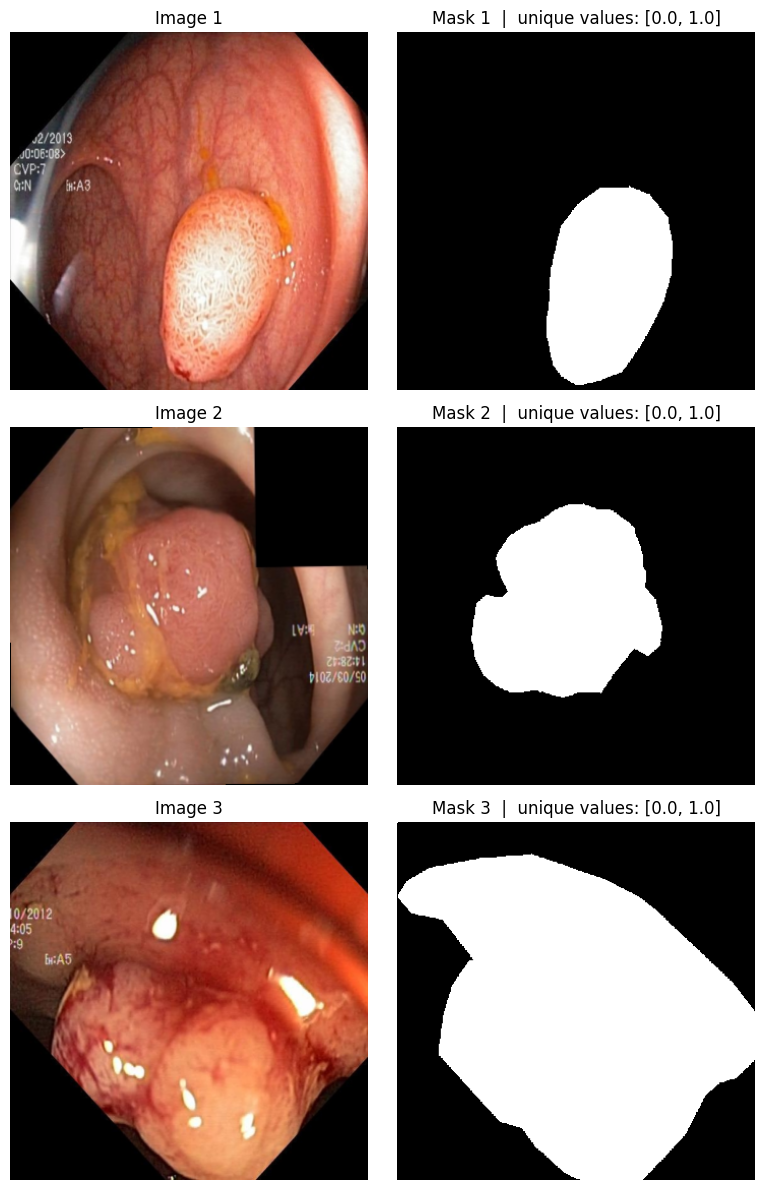

In [9]:
def denormalize(tensor):
    """Reverse ImageNet normalization for visualization."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


fig, axes = plt.subplots(3, 2, figsize=(8, 12))
for i in range(3):
    img, msk = train_dataset[i]
    axes[i, 0].imshow(denormalize(img).permute(1, 2, 0))
    axes[i, 0].set_title(f'Image {i+1}')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(msk.squeeze(), cmap='gray')
    axes[i, 1].set_title(f'Mask {i+1}  |  unique values: {msk.unique().tolist()}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Step 7: SETR-PUP Model
### Architecture
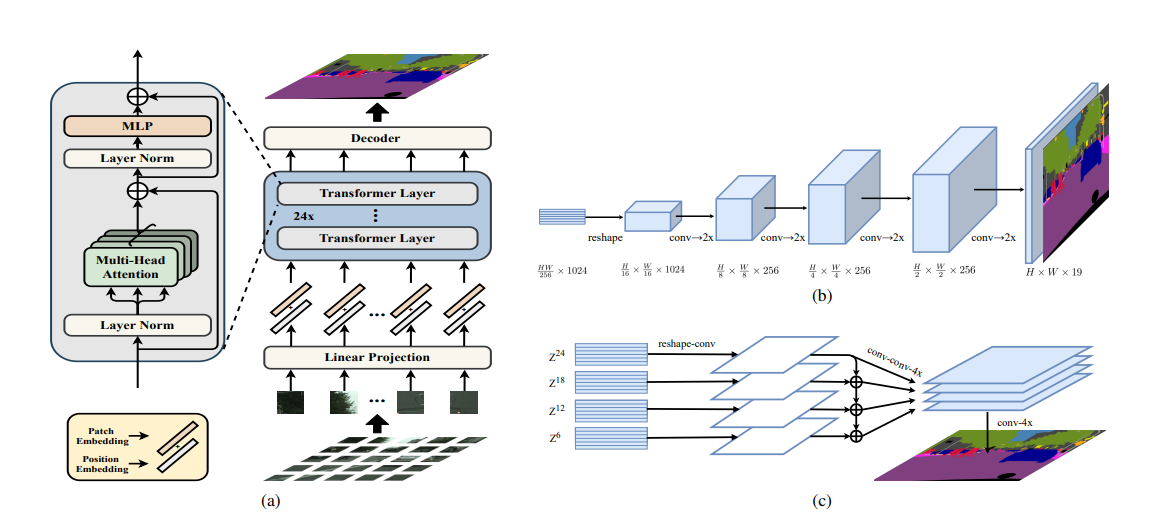

### Encoder: ViT-Base (from `timm`)

I load `vit_base_patch16_384` pretrained on ImageNet-21k. We override `img_size=352` — timm handles the positional embedding interpolation automatically.

I extract the **intermediate token sequence** after all 12 Transformer layers, then reshape from `(B, 484, 768)` back to `(B, 768, 22, 22)` — a 2D spatial feature map.

### Decoder: Progressive UPsampling (PUP)

The PUP decoder takes the `(B, 768, 22, 22)` feature map and progressively upsamples to full resolution:

```
22×22  →  Conv+BN+ReLU  →  2×  →  44×44
44×44  →  Conv+BN+ReLU  →  2×  →  88×88
88×88  →  Conv+BN+ReLU  →  2×  →  176×176
176×176 → Conv+BN+ReLU  →  2×  →  352×352
         → Conv 1×1 → sigmoid  →  Final mask
```

4 steps of 2× upsample = 16× total, matching the original 16× patch downsampling. Each step refines spatial detail through a conv before upsampling — preventing the blurriness of a single 16× jump.

In [12]:
class PUPDecoder(nn.Module):
    """
    Progressive UPsampling Decoder from SETR.

    Takes the reshaped ViT output (B, embed_dim, H/16, W/16)
    and progressively upsamples 4 × 2x back to (B, 1, H, W).

    Each stage:
        Conv(in → out, 3×3) → BN → ReLU → Bilinear 2×
    Final:
        Conv(out → 1, 1×1) → output logit
    """

    def __init__(self, embed_dim=768, channels=256):
        super().__init__()

        def up_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            )

        self.stage1 = up_block(embed_dim, channels)     # 768  → 256 | 22→44
        self.stage2 = up_block(channels,  channels)     # 256  → 256 | 44→88
        self.stage3 = up_block(channels,  channels)     # 256  → 256 | 88→176
        self.stage4 = up_block(channels,  channels)     # 256  → 256 | 176→352

        # Final 1×1 conv: project to single-channel logit
        self.head = nn.Conv2d(channels, 1, kernel_size=1)

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.head(x)   # (B, 1, H, W) — raw logit


class SETR_PUP(nn.Module):
    """
    SETR with Progressive UPsampling decoder.

    Encoder : ViT-Base/16 pretrained on ImageNet-21k
    Decoder : PUP — 4 progressive 2× upsample stages

    Input  : (B, 3, 352, 352)
    Output : (B, 1, 352, 352)  — raw logit (use sigmoid for probability)
    """

    def __init__(self, img_size=352, pretrained=True, decoder_channels=256):
        super().__init__()

        self.img_size   = img_size
        self.patch_size = 16
        self.num_patches_side = img_size // self.patch_size  # 22

        # ── Encoder: ViT-Base/16 ──────────────────────────────────────
        # timm will interpolate positional embeddings from 384 → 352
        self.encoder = timm.create_model(
            'vit_base_patch16_384',
            pretrained=pretrained,
            img_size=img_size,
            num_classes=0,          # remove classification head
            global_pool='',         # return full token sequence, not pooled
        )

        embed_dim = self.encoder.embed_dim  # 768 for ViT-Base

        # ── Decoder: PUP ─────────────────────────────────────────────
        self.decoder = PUPDecoder(embed_dim=embed_dim, channels=decoder_channels)

    def forward(self, x):
        B = x.shape[0]

        # ── Encoder forward ──────────────────────────────────────────
        # tokens shape: (B, num_patches + 1, embed_dim)
        # +1 is the [CLS] token prepended by ViT
        tokens = self.encoder.forward_features(x)  # (B, 485, 768)

        # Remove [CLS] token — we only need patch tokens for segmentation
        patch_tokens = tokens[:, 1:, :]  # (B, 484, 768)

        # Reshape flat sequence → 2D spatial feature map
        H = W = self.num_patches_side   # 22
        patch_tokens = patch_tokens.permute(0, 2, 1)         # (B, 768, 484)
        patch_tokens = patch_tokens.reshape(B, -1, H, W)     # (B, 768, 22, 22)

        # ── Decoder forward ──────────────────────────────────────────
        logit = self.decoder(patch_tokens)   # (B, 1, 352, 352)

        return logit


# ── Instantiate and verify ────────────────────────────────────────────────────
model = SETR_PUP(img_size=IMG_SIZE, pretrained=True).to(DEVICE)

# Shape check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f'Input  shape : {dummy.shape}')
    print(f'Output shape : {out.shape}')   # expect (2, 1, 352, 352)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Total parameters : {total_params:.1f}M')

Input  shape : torch.Size([2, 3, 352, 352])
Output shape : torch.Size([2, 1, 352, 352])
Total parameters : 89.6M


## Step 8: Loss Function

I use **BCE + Dice loss** — the standard combination for polyp segmentation:

- **Binary Cross-Entropy (BCE):** penalizes each pixel independently — good for overall accuracy
- **Dice Loss:** directly optimizes the overlap metric (Dice coefficient) — critical when polyps are small and the foreground/background is imbalanced

Using both together is more stable than either alone.

In [13]:
class BCEDiceLoss(nn.Module):
    """
    Combined BCE + Dice Loss for binary segmentation.
    Input logits (before sigmoid) — sigmoid applied internally.
    """

    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1e-5):
        super().__init__()
        self.bce_weight  = bce_weight
        self.dice_weight = dice_weight
        self.smooth      = smooth
        self.bce         = nn.BCEWithLogitsLoss()

    def dice_loss(self, logits, targets):
        probs = torch.sigmoid(logits)
        # Flatten spatial dims
        probs   = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        dice = (2. * intersection + self.smooth) / \
               (probs.sum(dim=1) + targets.sum(dim=1) + self.smooth)
        return 1 - dice.mean()

    def forward(self, logits, targets):
        bce  = self.bce(logits, targets)
        dice = self.dice_loss(logits, targets)
        return self.bce_weight * bce + self.dice_weight * dice


criterion = BCEDiceLoss()
print('Loss function ready ✓')

Loss function ready ✓


## Step 9: Metrics

I track three metrics consistent with all other models in this blog series:

- **Dice Coefficient** (= F1 Score): measures overlap between prediction and ground truth — the primary polyp segmentation metric
- **IoU** (Intersection over Union / Jaccard Index): stricter overlap metric
- **Pixel Accuracy**: fraction of correctly classified pixels — least informative for imbalanced data but included for completeness

In [14]:
def compute_metrics(logits, targets, threshold=0.5):
    """
    Compute Dice, IoU, and Pixel Accuracy.

    Args:
        logits  : (B, 1, H, W) raw model output
        targets : (B, 1, H, W) binary ground truth {0.0, 1.0}
    Returns:
        dict with 'dice', 'iou', 'pixel_acc'
    """
    preds = (torch.sigmoid(logits) > threshold).float()

    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    smooth = 1e-5

    intersection = (preds * targets).sum(dim=1)
    union        = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    dice      = ((2 * intersection + smooth) / (preds.sum(dim=1) + targets.sum(dim=1) + smooth)).mean()
    iou       = ((intersection + smooth) / (union + smooth)).mean()
    pixel_acc = (preds == targets).float().mean()

    return {
        'dice'      : dice.item(),
        'iou'       : iou.item(),
        'pixel_acc' : pixel_acc.item()
    }

print('Metrics function ready ✓')

Metrics function ready ✓


## Step 10: Optimizer & Scheduler

### Optimizer: AdamW
AdamW (Adam with decoupled weight decay) is the standard optimizer for Transformer-based models. I use a small learning rate (`1e-4`) because:
- The ViT encoder is **pretrained** — I want to fine-tune gently, not destroy learned features
- Pure Transformer models are sensitive to large learning rates

### Differential Learning Rates
I set a **lower learning rate for the encoder** (pretrained) and a **higher rate for the decoder** (randomly initialized). This is best practice for fine-tuning pretrained Transformers:

| Component | LR | Reason |
|---|---|---|
| ViT Encoder | 1e-5 | Pretrained — fine-tune gently |
| PUP Decoder | 1e-4 | Randomly initialized — needs to learn fast |

### Scheduler: Cosine Annealing
Gradually reduces LR following a cosine curve — helps the model converge smoothly in the final epochs.

In [15]:
NUM_EPOCHS = 50

# Differential learning rates: lower for pretrained encoder
optimizer = torch.optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.decoder.parameters(), 'lr': 1e-4, 'weight_decay': 1e-4},
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print(f'Optimizer : AdamW  |  Encoder LR : 1e-5  |  Decoder LR : 1e-4')
print(f'Scheduler : CosineAnnealingLR  |  Epochs : {NUM_EPOCHS}')

Optimizer : AdamW  |  Encoder LR : 1e-5  |  Decoder LR : 1e-4
Scheduler : CosineAnnealingLR  |  Epochs : 50


## Step 11: Training Loop

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_dice = 0

    for images, masks in tqdm(loader, desc='Training', leave=False):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, masks)
        loss.backward()

        # Gradient clipping — important for Transformer stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        metrics = compute_metrics(logits.detach(), masks)
        total_loss += loss.item()
        total_dice += metrics['dice']

    n = len(loader)
    return total_loss / n, total_dice / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_dice = 0
    total_iou  = 0
    total_acc  = 0

    for images, masks in tqdm(loader, desc='Evaluating', leave=False):
        images, masks = images.to(device), masks.to(device)

        logits  = model(images)
        loss    = criterion(logits, masks)
        metrics = compute_metrics(logits, masks)

        total_loss += loss.item()
        total_dice += metrics['dice']
        total_iou  += metrics['iou']
        total_acc  += metrics['pixel_acc']

    n = len(loader)
    return {
        'loss'      : total_loss / n,
        'dice'      : total_dice / n,
        'iou'       : total_iou  / n,
        'pixel_acc' : total_acc  / n
    }

In [17]:
# ── Training ───────────────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_dice': [],
    'val_loss':   [], 'val_dice':   [], 'val_iou': []
}

best_val_dice = 0.0
SAVE_PATH     = '/kaggle/working/setr_pup_best.pth'

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics            = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    # Log
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_metrics['loss'])
    history['val_dice'].append(val_metrics['dice'])
    history['val_iou'].append(val_metrics['iou'])

    # Save best model
    if val_metrics['dice'] > best_val_dice:
        best_val_dice = val_metrics['dice']
        torch.save(model.state_dict(), SAVE_PATH)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
              f"Train Loss: {train_loss:.4f}  Train Dice: {train_dice:.4f}  "
              f"Val Loss: {val_metrics['loss']:.4f}  Val Dice: {val_metrics['dice']:.4f}  "
              f"Val IoU: {val_metrics['iou']:.4f}")

print(f'\nBest Val Dice: {best_val_dice:.4f}  |  Model saved to {SAVE_PATH}')

Epoch [01/50]  Train Loss: 0.3383  Train Dice: 0.7705  Val Loss: 0.2362  Val Dice: 0.8443  Val IoU: 0.7468


Epoch [05/50]  Train Loss: 0.1021  Train Dice: 0.9139  Val Loss: 0.0994  Val Dice: 0.9125  Val IoU: 0.8482


Epoch [10/50]  Train Loss: 0.0584  Train Dice: 0.9432  Val Loss: 0.0855  Val Dice: 0.9169  Val IoU: 0.8567


Epoch [15/50]  Train Loss: 0.0458  Train Dice: 0.9536  Val Loss: 0.0989  Val Dice: 0.9108  Val IoU: 0.8501


Epoch [20/50]  Train Loss: 0.0364  Train Dice: 0.9610  Val Loss: 0.0906  Val Dice: 0.9131  Val IoU: 0.8552


...

Epoch [30/50]  Train Loss: 0.0291  Train Dice: 0.9681  Val Loss: 0.0843  Val Dice: 0.9221  Val IoU: 0.8675


Epoch [35/50]  Train Loss: 0.0257  Train Dice: 0.9717  Val Loss: 0.0816  Val Dice: 0.9266  Val IoU: 0.8731


Epoch [40/50]  Train Loss: 0.0243  Train Dice: 0.9735  Val Loss: 0.0866  Val Dice: 0.9228  Val IoU: 0.8683


Epoch [45/50]  Train Loss: 0.0227  Train Dice: 0.9750  Val Loss: 0.0895  Val Dice: 0.9221  Val IoU: 0.8671


Epoch [50/50]  Train Loss: 0.0222  Train Dice: 0.9757  Val Loss: 0.0910  Val Dice: 0.9213  Val IoU: 0.8659

Best Val Dice: 0.9274  |  Model saved to /kaggle/working/setr_pup_best.pth


## Step 12: Training Curves

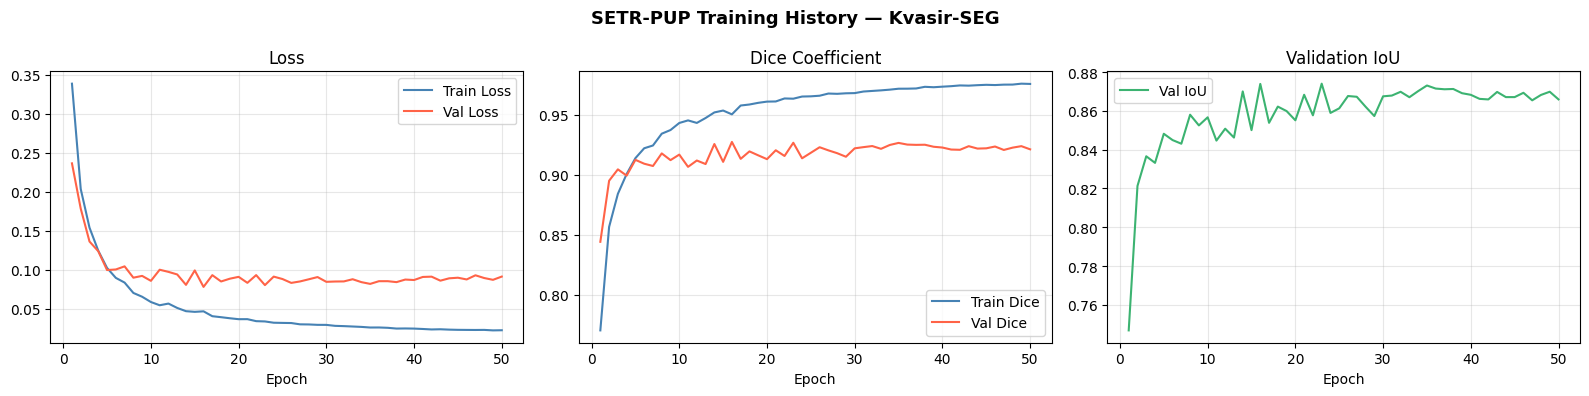

In [19]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_dice'], label='Train Dice', color='steelblue')
axes[1].plot(epochs, history['val_dice'],   label='Val Dice',   color='tomato')
axes[1].set_title('Dice Coefficient')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['val_iou'], label='Val IoU', color='mediumseagreen')
axes[2].set_title('Validation IoU')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('SETR-PUP Training History — Kvasir-SEG', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 13: Test Set Evaluation

Load the best checkpoint and evaluate on the held-out test set.

In [20]:
# Load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
print('Best checkpoint loaded ✓')

# Evaluate on test set
test_metrics = evaluate(model, test_loader, criterion, DEVICE)

print('\n' + '='*50)
print('  SETR-PUP — Test Set Results')
print('='*50)
print(f"  Dice Coefficient : {test_metrics['dice']:.4f}")
print(f"  IoU (Jaccard)    : {test_metrics['iou']:.4f}")
print(f"  Pixel Accuracy   : {test_metrics['pixel_acc']:.4f}")
print(f"  Test Loss        : {test_metrics['loss']:.4f}")
print('='*50)

Best checkpoint loaded ✓



  SETR-PUP — Test Set Results
  Dice Coefficient : 0.9210
  IoU (Jaccard)    : 0.8664
  Pixel Accuracy   : 0.9760
  Test Loss        : 0.0884


## Step 14: Qualitative Visualization

Visual inspection of predictions is as important as numbers. We overlay the predicted mask on the original image to see how well SETR captures polyp boundaries.

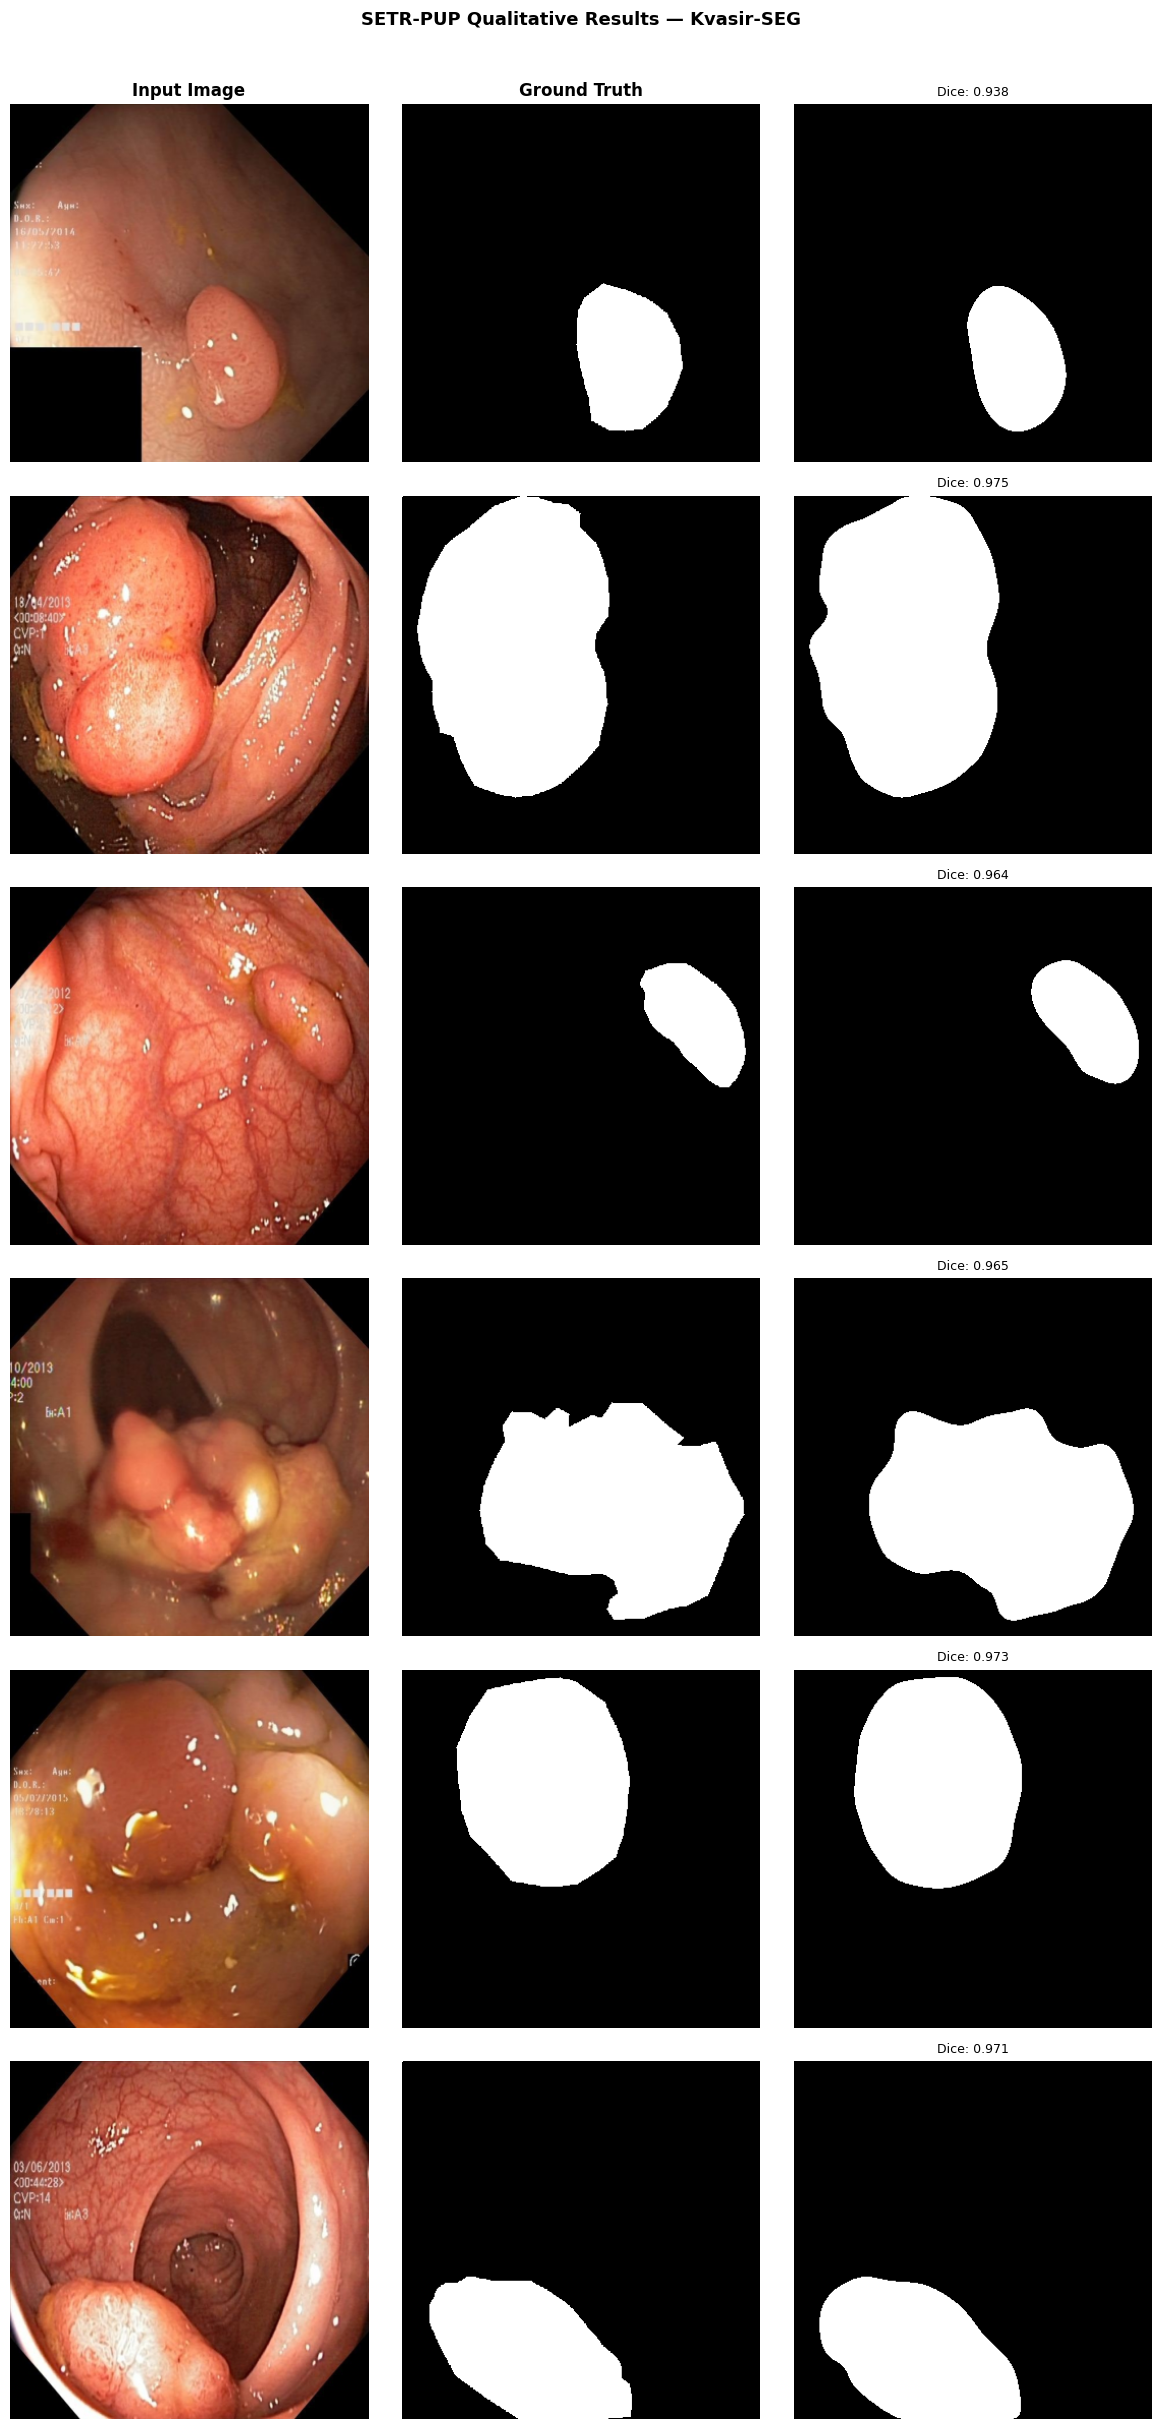

In [21]:
model.eval()

# Pick 6 random test samples
indices = random.sample(range(len(test_dataset)), 6)

fig, axes = plt.subplots(6, 3, figsize=(12, 24))
col_titles = ['Input Image', 'Ground Truth', 'SETR-PUP Prediction']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

with torch.no_grad():
    for row, idx in enumerate(indices):
        image, mask = test_dataset[idx]
        logit = model(image.unsqueeze(0).to(DEVICE))
        pred  = (torch.sigmoid(logit) > 0.5).float().squeeze().cpu()

        dice = compute_metrics(logit.cpu(), mask.unsqueeze(0))['dice']

        axes[row, 0].imshow(denormalize(image).permute(1, 2, 0))
        axes[row, 0].axis('off')

        axes[row, 1].imshow(mask.squeeze(), cmap='gray')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(pred, cmap='gray')
        axes[row, 2].set_title(f'Dice: {dice:.3f}', fontsize=9)
        axes[row, 2].axis('off')

plt.suptitle('SETR-PUP Qualitative Results — Kvasir-SEG', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()